# Taller 10 – Embeddings y LLM
Tomas Charria y Emilio Gomex


---
# Ejercicio 1: Sistema RAG con Gemini

Implementa un sistema RAG (Retrieval-Augmented Generation) que:
1. Lee un PDF y lo divide en chunks
2. Genera embeddings de cada chunk con `sentence-transformers`
3. Recupera los fragmentos más relevantes por similitud de coseno
4. Usa Gemini para generar la respuesta final
5. Expone una interfaz Gradio

In [1]:
# Instalar dependencias del Ejercicio 1
!pip install -q google-generativeai pypdf gradio sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 6.4 MB/s eta 0:00:00


In [10]:
import os
import numpy as np
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from google.colab import userdata
import google.generativeai as genai
import gradio as gr

In [13]:


# Ensure you have stored your API key with the name 'GEMINI_API_KEY' in Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)
print('API Key configurada correctamente.')

API Key configurada correctamente.


In [15]:
# ── 1. Leer el PDF ────────────────────────────────────────────────────────────
PDF_PATH = '/content/Polymarket US Rulebook (2026.04.21).pdf'

def extract_text_from_pdf(path: str) -> str:
    reader = PdfReader(path)
    return '\n'.join(page.extract_text() or '' for page in reader.pages)

full_text = extract_text_from_pdf(PDF_PATH)
print(f'Texto extraído: {len(full_text)} caracteres')
print(full_text[:500])

Texto extraído: 210946 caracteres
 
 
 
 
 
POLYMARKET US RULEBOOK 
 
 
March 20, 2026 
 
BY ACCESSING, OR ENTERING ANY ORDER INTO, THE TRADING SYSTEM, AND 
WITHOUT ANY NEED FOR ANY FURTHER ACTION, UNDERTAKING OR AGREEMENT, 
A PARTICIPANT (INCLUDING) ITS AUTHORIZED USERS AND RESPONSIBLE 
AGENTS) AGREE (I) TO BE BOUND BY, AND COMPLY WITH, THE RULES  OF 
POLYMARKET US, ANY APPLICABLE CONTRACT RULES AND APPLICABLE LAW, IN 
EACH CASE TO THE EXTENT APPLICABLE TO IT OR THEM, AND (II) TO BECOME 
SUBJECT TO THE JURISDICTION OF POLYMARKE


In [16]:
# ── 2. Dividir en chunks ──────────────────────────────────────────────────────
def split_into_chunks(text: str, chunk_size: int = 500, overlap: int = 50) -> list:
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(' '.join(words[start:end]))
        start += chunk_size - overlap
    return chunks

chunks = split_into_chunks(full_text)
print(f'Total de chunks: {len(chunks)}')
print('Primer chunk:\n', chunks[0][:300])

Total de chunks: 71
Primer chunk:
 POLYMARKET US RULEBOOK March 20, 2026 BY ACCESSING, OR ENTERING ANY ORDER INTO, THE TRADING SYSTEM, AND WITHOUT ANY NEED FOR ANY FURTHER ACTION, UNDERTAKING OR AGREEMENT, A PARTICIPANT (INCLUDING) ITS AUTHORIZED USERS AND RESPONSIBLE AGENTS) AGREE (I) TO BE BOUND BY, AND COMPLY WITH, THE RULES OF PO


In [17]:
# ── 3. Generar embeddings con sentence-transformers ───────────────────────────
print('Cargando modelo de embeddings...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print('Generando embeddings de los chunks...')
chunk_embeddings = embedder.encode(chunks, show_progress_bar=True, convert_to_numpy=True)
print(f'Shape de embeddings: {chunk_embeddings.shape}')

Cargando modelo de embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings de los chunks...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Shape de embeddings: (71, 384)


In [18]:
# ── 4. Función de recuperación por similitud de coseno ───────────────────────
def cosine_similarity_rag(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a_norm = a / (np.linalg.norm(a) + 1e-10)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10)
    return b_norm @ a_norm

def retrieve_top_k(query: str, k: int = 5) -> list:
    query_emb = embedder.encode([query], convert_to_numpy=True)[0]
    scores = cosine_similarity_rag(query_emb, chunk_embeddings)
    top_indices = np.argsort(scores)[::-1][:k]
    return [chunks[i] for i in top_indices]

# Prueba rápida
test_results = retrieve_top_k('¿Cuál es el objetivo del reglamento?', k=3)
for i, r in enumerate(test_results):
    print(f'--- Chunk {i+1} ---\n{r[:200]}\n')

--- Chunk 1 ---
criminal, administrative, or investiga tive in nature, by reason of the fact that such person is or was Company Personnel against expenses, including attorneys’ fees, judgments, fines, and amounts pai

--- Chunk 2 ---
in which the Orders were received. CHAPTER 8 RULE ENFORCEMENT 8.1. General (a) The Company will conduct inquiries, investigations, disciplinary proceedings and appeals from disciplinary proceedings, s

--- Chunk 3 ---
duties, liabilities, limitations, obligations, responsibilities, and rights of a Participant, and of the Company with regard to each Participant, shall be interpreted to be a duty, liability, limitati



In [20]:
# ── 5. Función RAG: recuperar + generar respuesta con Gemini ─────────────────
model_gemini = genai.GenerativeModel('gemini-3-flash-preview')

def rag_answer(question: str) -> str:
    relevant_chunks = retrieve_top_k(question, k=5)
    context = '\n\n'.join(relevant_chunks)
    prompt = f"""Eres un asistente experto. Usa ÚNICAMENTE el siguiente contexto extraído de un documento para responder la pregunta.
Si la respuesta no está en el contexto, responde: 'No encontré información sobre eso en el documento.'

CONTEXTO:
{context}

PREGUNTA: {question}

RESPUESTA:"""
    response = model_gemini.generate_content(prompt)
    return response.text

# Prueba
print(rag_answer('¿De qué trata el documento?'))

Basado en el contexto proporcionado, el documento trata sobre las **reglas, obligaciones y procedimientos disciplinarios** de una "Compañía" (aparentemente una plataforma de intercambio o trading) aplicables a sus **Participantes y Usuarios Autorizados**.

Los temas principales que aborda son:

1.  **Obligaciones de los Participantes:** Incluye la responsabilidad de mantenerse informados sobre cambios en las reglas, proporcionar direcciones de correo electrónico actualizadas y supervisar diligentemente a sus empleados y agentes.
2.  **Mantenimiento de Registros y Auditoría:** Exige conservar libros, registros y pistas de auditoría (audit trails) conforme a las regulaciones de la CFTC y la CEA, permitiendo inspecciones por parte de la Compañía y autoridades gubernamentales.
3.  **Notificaciones Obligatorias:** Los participantes deben informar inmediatamente a la Compañía sobre suspensiones en otros mercados, condenas penales, procesos regulatorios, quiebras o cambios materiales que afec

In [21]:
# ── 6. Interfaz Gradio – Ejercicio 1 ─────────────────────────────────────────
def gradio_rag(question: str) -> str:
    if not question.strip():
        return 'Por favor escribe una pregunta.'
    return rag_answer(question)

with gr.Blocks(title='RAG con Gemini') as demo_rag:
    gr.Markdown('# Sistema RAG con Gemini\nHaz preguntas sobre el documento cargado.')
    with gr.Row():
        question_input = gr.Textbox(
            label='Tu pregunta',
            placeholder='Ej: ¿Cuáles son los requisitos para...?',
            lines=2
        )
    submit_btn = gr.Button('Preguntar', variant='primary')
    answer_output = gr.Textbox(label='Respuesta', lines=8)

    submit_btn.click(fn=gradio_rag, inputs=question_input, outputs=answer_output)
    question_input.submit(fn=gradio_rag, inputs=question_input, outputs=answer_output)

demo_rag.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f6a37838ee7e786ead.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f6a37838ee7e786ead.gradio.live



# Ejercicio 2: Generación de Embeddings y Visualización t-SNE



In [22]:
# Instalar dependencias del Ejercicio 2
!pip install -q tensorflow tensorflow-hub scikit-learn matplotlib Pillow requests

In [23]:
import requests
from pathlib import Path
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize



TensorFlow: 2.20.0


In [27]:
# ── 1. Descargar imágenes de referencia desde CIFAR-10 (tensorflow_datasets) ──
# CIFAR-10 viene preinstalado en Colab — no necesita URLs externas ni autenticación.
# Clases usadas: airplane=0, automobile=1, cat=3, dog=5
import tensorflow_datasets as tfds

CIFAR_CATS = {0: 'avion', 1: 'carro', 3: 'gato', 5: 'perro'}
N_PER_CLASS = 6  # 6 imágenes × 4 categorías = 24 en total

IMG_DIR = Path('imagenes_referencia')
IMG_DIR.mkdir(exist_ok=True)

print('Cargando CIFAR-10 (split de prueba)...')
ds = tfds.load('cifar10', split='test', as_supervised=True, shuffle_files=False)

counters = {k: 0 for k in CIFAR_CATS}
all_imgs = []

for img_tensor, label_tensor in ds:
    label = int(label_tensor.numpy())
    if label not in CIFAR_CATS or counters[label] >= N_PER_CLASS:
        continue

    cat = CIFAR_CATS[label]
    counters[label] += 1
    filename = f'{cat}_{counters[label]}.jpg'
    dest = IMG_DIR / filename

    if not dest.exists():
        # Upscale 32×32 → 224×224 para que MobileNet tenga buena resolución
        img = Image.fromarray(img_tensor.numpy()).resize((224, 224), Image.LANCZOS)
        img.save(dest)

    all_imgs.append((str(dest), cat))
    print(f'OK: {filename} [{cat}]')

    if all(v >= N_PER_CLASS for v in counters.values()):
        break

print(f'\nTotal imágenes: {len(all_imgs)}')
print(Counter(cat for _, cat in all_imgs))

Cargando CIFAR-10 (split de prueba)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.4DMGVD_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.4DMGVD_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
OK: avion_1.jpg [avion]
OK: perro_1.jpg [perro]
OK: carro_1.jpg [carro]
OK: avion_2.jpg [avion]
OK: gato_1.jpg [gato]
OK: gato_2.jpg [gato]
OK: perro_2.jpg [perro]
OK: avion_3.jpg [avion]
OK: avion_4.jpg [avion]
OK: carro_2.jpg [carro]
OK: avion_5.jpg [avion]
OK: avion_6.jpg [avion]
OK: carro_3.jpg [carro]
OK: perro_3.jpg [perro]
OK: carro_4.jpg [carro]
OK: perro_4.jpg [perro]
OK: gato_3.jpg [gato]
OK: perro_5.jpg [perro]
OK: perro_6.jpg [perro]
OK: gato_4.jpg [gato]
OK: carro_5.jpg [carro]
OK: carro_6.jpg [carro]
OK: gato_5.jpg [gato]
OK: gato_6.jpg [gato]

Total imágenes: 24
Counter({'avion': 6, 'perro': 6, 'carro': 6, 'gato': 6})


In [26]:
# ── 2. Cargar modelo MobileNet V2 desde TensorFlow Hub ───────────────────────
MODEL_URL = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'
print('Cargando MobileNet V2...')
feature_extractor = hub.KerasLayer(MODEL_URL, input_shape=(224, 224, 3), trainable=False)
print('Modelo cargado.')

Cargando MobileNet V2...
Modelo cargado.


In [28]:
# ── 3. Función para generar embedding de una imagen ──────────────────────────
def get_image_embedding(img_path: str) -> np.ndarray:
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, 224, 224, 3)
    return feature_extractor(arr).numpy()[0]  # (1280,)

# Prueba
sample_emb = get_image_embedding(all_imgs[0][0])
print(f'Shape del embedding: {sample_emb.shape}')

Shape del embedding: (1280,)


In [29]:
# ── 4. Generar embeddings de todas las imágenes de referencia ────────────────
valid_imgs, img_embeddings, img_labels = [], [], []

for img_path, category in all_imgs:
    try:
        emb = get_image_embedding(img_path)
        valid_imgs.append(img_path)
        img_embeddings.append(emb)
        img_labels.append(category)
        print(f'OK: {Path(img_path).name} [{category}]')
    except Exception as e:
        print(f'Error en {Path(img_path).name}: {e}')

img_embeddings = np.array(img_embeddings)
img_embeddings_norm = normalize(img_embeddings)
print(f'\nEmbeddings generados: {img_embeddings.shape}')

OK: avion_1.jpg [avion]
OK: perro_1.jpg [perro]
OK: carro_1.jpg [carro]
OK: avion_2.jpg [avion]
OK: gato_1.jpg [gato]
OK: gato_2.jpg [gato]
OK: perro_2.jpg [perro]
OK: avion_3.jpg [avion]
OK: avion_4.jpg [avion]
OK: carro_2.jpg [carro]
OK: avion_5.jpg [avion]
OK: avion_6.jpg [avion]
OK: carro_3.jpg [carro]
OK: perro_3.jpg [perro]
OK: carro_4.jpg [carro]
OK: perro_4.jpg [perro]
OK: gato_3.jpg [gato]
OK: perro_5.jpg [perro]
OK: perro_6.jpg [perro]
OK: gato_4.jpg [gato]
OK: carro_5.jpg [carro]
OK: carro_6.jpg [carro]
OK: gato_5.jpg [gato]
OK: gato_6.jpg [gato]

Embeddings generados: (24, 1280)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


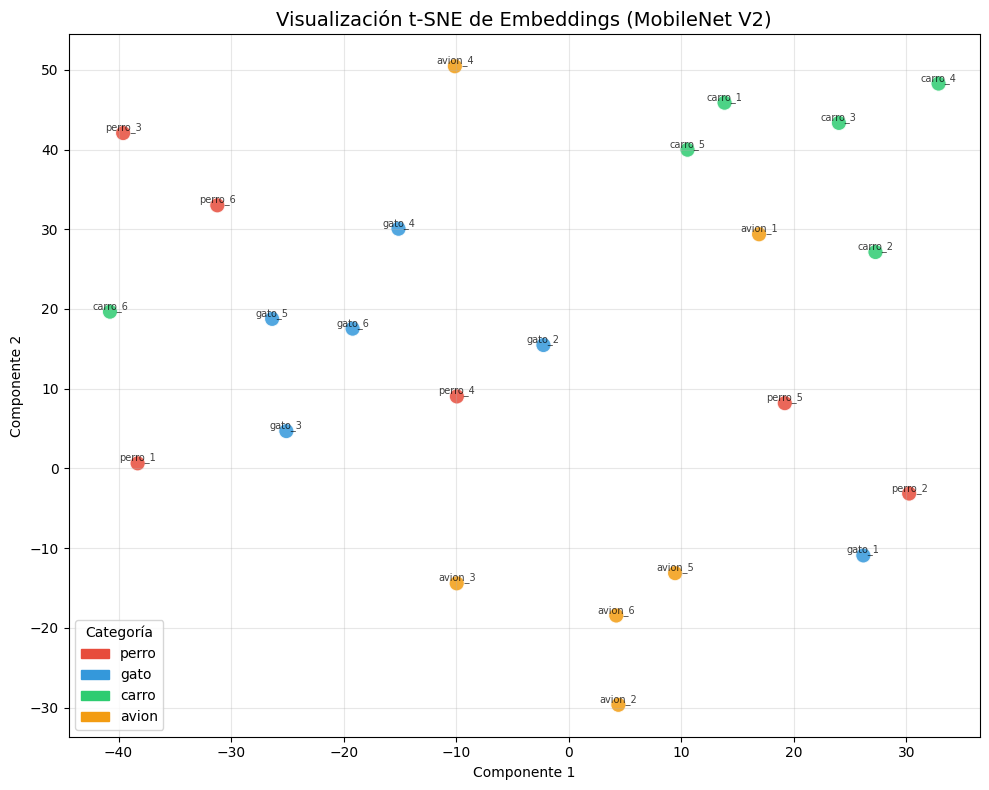

Guardado: tsne_visualization.png


In [30]:
# ── 5. Visualización t-SNE ───────────────────────────────────────────────────
perplexity = min(5, len(img_embeddings) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(img_embeddings)

color_map = {'perro': '#e74c3c', 'gato': '#3498db', 'carro': '#2ecc71', 'avion': '#f39c12'}
colors = [color_map[l] for l in img_labels]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
           c=colors, s=120, alpha=0.85, edgecolors='white', linewidths=0.8)

for i, (x, y) in enumerate(embeddings_2d):
    ax.annotate(Path(valid_imgs[i]).stem, (x, y), fontsize=7,
                ha='center', va='bottom', alpha=0.75)

legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in color_map.items()]
ax.legend(handles=legend_patches, title='Categoría', loc='best')
ax.set_title('Visualización t-SNE de Embeddings (MobileNet V2)', fontsize=14)
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150)
plt.show()
print('Guardado: tsne_visualization.png')

In [31]:
# ── 6. Función de búsqueda semántica por similitud de coseno ─────────────────
def find_similar_images(query_path: str, top_k: int = 5) -> list:
    query_emb = get_image_embedding(query_path)
    query_norm = query_emb / (np.linalg.norm(query_emb) + 1e-10)
    similarities = img_embeddings_norm @ query_norm
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return [(valid_imgs[i], float(similarities[i]), img_labels[i]) for i in top_indices]

# Prueba
results = find_similar_images(valid_imgs[0], top_k=3)
for path, score, cat in results:
    print(f'{Path(path).name} [{cat}] — similitud: {score:.4f}')

avion_1.jpg [avion] — similitud: 1.0000
carro_2.jpg [carro] — similitud: 0.6712
carro_3.jpg [carro] — similitud: 0.6102


In [32]:
# ── 7. Interfaz Gradio – Ejercicio 2 ─────────────────────────────────────────
def run_search(img, k):
    if img is None:
        return [None] * 5 + ['Sube una imagen primero.']
    tmp_path = '/tmp/query_image.jpg'
    Image.fromarray(img).convert('RGB').save(tmp_path)
    results = find_similar_images(tmp_path, top_k=int(k))
    output, lines = [], []
    for rank, (path, score, cat) in enumerate(results, 1):
        output.append(np.array(Image.open(path).convert('RGB')))
        lines.append(f'{rank}. {Path(path).name} [{cat}] — similitud: {score:.4f}')
    while len(output) < 5:
        output.append(None)
    return output + ['\n'.join(lines)]

with gr.Blocks(title='Búsqueda Semántica de Imágenes') as demo_img:
    gr.Markdown('# Búsqueda Semántica de Imágenes\nSube una imagen y encuentra las más similares usando **MobileNet V2 + similitud de coseno**.')

    with gr.Row():
        with gr.Column(scale=1):
            query_img = gr.Image(label='Imagen de consulta', type='numpy')
            top_k_slider = gr.Slider(minimum=1, maximum=min(5, len(valid_imgs)),
                                     value=3, step=1, label='Número de resultados')
            search_btn = gr.Button('Buscar imágenes similares', variant='primary')
        with gr.Column(scale=2):
            gr.Markdown('### Resultados más similares')
            result_imgs = [gr.Image(label=f'Top {i+1}') for i in range(5)]
            info_text = gr.Textbox(label='Detalles de similitud', lines=6)

    search_btn.click(fn=run_search, inputs=[query_img, top_k_slider],
                     outputs=result_imgs + [info_text])

    gr.Markdown('### Muestra del conjunto de referencia')
    with gr.Row():
        for path, cat in list(zip(valid_imgs, img_labels))[:8]:
            gr.Image(value=path, label=f'[{cat}] {Path(path).stem}', width=150)

demo_img.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://eff396dc262ce8e190.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://eff396dc262ce8e190.gradio.live
